# Micro-models — porównanie zamrożonych modeli

## tl;dr

**Najlepszym pojedynczym modelem tej serii jest NPLM; najlepszy wynik predykcyjny uzyskało połączenie NPLM z GPT.** Na odłożonym teście NPLM osiągnął PPL 1,9501, GPT B 2,0375, a n-gram z kontekstem 6 znaków 2,2505. Uśrednienie logitów NPLM i GPT B dało 1,8595: o 4,65% mniej niż NPLM i o 8,74% mniej niż GPT B. Mniejsza perplexity oznacza lepsze przypisywanie prawdopodobieństwa rzeczywistym kolejnym znakom.

Przewaga NPLM nad GPT B wynosi 4,29% PPL. Sparowany bootstrap całych rodzin melodii daje 95% przedział ilorazu PPL 0,929–0,988, co w tej próbie wspiera kierunek różnicy. Test liczy tylko 17 rodzin; wynik nie dowodzi ogólnej wyższości NPLM nad transformerami.

Przewidywanie znaków pozostaje wyraźnie lepsze niż niezawodność generowania. Spośród 30 ustalonych próbek każdego modelu warunek zakończenia i braku wykrytych błędów długości taktów wewnętrznych spełniło 15 NPLM, 7 GPT A i 3 GPT B. Jest to diagnostyka techniczna, a nie ocena muzykalności.

Zamknięto końcową ewaluację pierwszego pilotażu Bach. Nie wykonywano dodatkowego treningu ani strojenia na teście. Test został teraz wykorzystany i nie jest już świeżym zbiorem do kolejnych decyzji badawczych.

## Context & Methods

Notebook odtwarza tabele i wykresy z zapisanych, pojedynczych strat znakowych oraz wyników pomiarów. Aby ponowić inferencję, uruchom `evaluate_campaign.py`; generacje: `generate_evaluation.py`; CKA: `analyze_representations.py`. Nie uruchamia treningu.

### Key Assumptions

Wspólny podział 281/36/35, brak zmiany wag, EOS poza metryką. 95% przedziały są warunkowe na wagach i jednym podziale; bootstrap obejmuje rodziny, nie niezależne znaki. Źródła i kod są w tej samej paczce.

In [1]:
from pathlib import Path
import json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
P=Path.cwd()
if not (P/'results.json').exists(): P=P/'evaluation_20260926'
R=json.loads((P/'results.json').read_text()); G=json.loads((P/'generation.json').read_text()); C=json.loads((P/'representations.json').read_text())
T=np.load(P/'token_scores.npz')
labels={'ngram_context1': 'N-gram 1', 'ngram_context3': 'N-gram 3', 'ngram_context6': 'N-gram 6', 'NPLM': 'NPLM', 'GPT_A': 'GPT A', 'GPT_B': 'GPT B', 'GPT_AB_prob': 'GPT A+B: prawdopodobieństwa', 'GPT_AB_logits': 'GPT A+B: logity', 'NPLM_GPT_B_prob': 'NPLM+GPT B: prawdopodobieństwa', 'NPLM_GPT_B_logits': 'NPLM+GPT B: logity'}
plt.rcParams.update({'figure.figsize':(10,5),'font.size':11,'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':.18,'figure.dpi':130})
(P/'figures').mkdir(exist_ok=True)
def finish(name):
    plt.tight_layout();plt.savefig(P/'figures'/name,bbox_inches='tight');display(Image(filename=str(P/'figures'/name)));plt.close()


## Data

Test: 35 melodii, 17 rodzin, 8299 znaków, w tym 7568 znaków części muzycznej. Ponowne obliczenie metryk poniżej używa wszystkich zapisanych strat, bez odczytywania zaokrąglonych wartości tabeli.

In [2]:
body=T['test__body']; rows=[]
for n,v in R['test']['models'].items():
    ppl=float(np.exp(T['test__'+n+'__nll'][body].mean()))
    assert abs(ppl-v['body_ppl'])<1e-12
    rows.append({'Model':labels[n],'Walidacja PPL':R['validation']['models'][n]['body_ppl'],'Test PPL':ppl,'Dolne 95%':v['body_ppl_ci95'][0],'Górne 95%':v['body_ppl_ci95'][1],'Bity/znak':v['body_bpc']})
df=pd.DataFrame(rows).sort_values('Test PPL')
display(df.round(4))
assert len(body)==8299 and int(body.sum())==7568


,Model,Walidacja PPL,Test PPL,Dolne 95%,Górne 95%,Bity/znak
9,NPLM+GPT B: logity,1.8111,1.8595,1.7813,1.9426,0.8949
8,NPLM+GPT B: prawdopodobieństwa,1.8347,1.8792,1.8045,1.9582,0.9101
0,NPLM,1.8970,1.9501,1.8559,2.0463,0.9636
6,GPT A+B: prawdopodobieństwa,1.9558,2.0159,1.9289,2.1139,1.0114
7,GPT A+B: logity,1.9572,2.0188,1.9305,2.1191,1.0135
2,GPT B,1.9747,2.0375,1.9408,2.1492,1.0268
1,GPT A,1.9828,2.0443,1.9598,2.1378,1.0316
5,N-gram 6,2.1955,2.2505,2.1622,2.3477,1.1702
4,N-gram 3,2.7369,2.7423,2.6445,2.8525,1.4554
3,N-gram 1,3.8358,3.8455,3.7288,3.9763,1.9432


## Results

### 1. Porównanie predykcji

Punkty i przedziały: PPL muzycznej części testu; mniej = lepiej. Przedziały 95% po 10 tys. losowań rodzin, bez niepewności ponownego treningu.

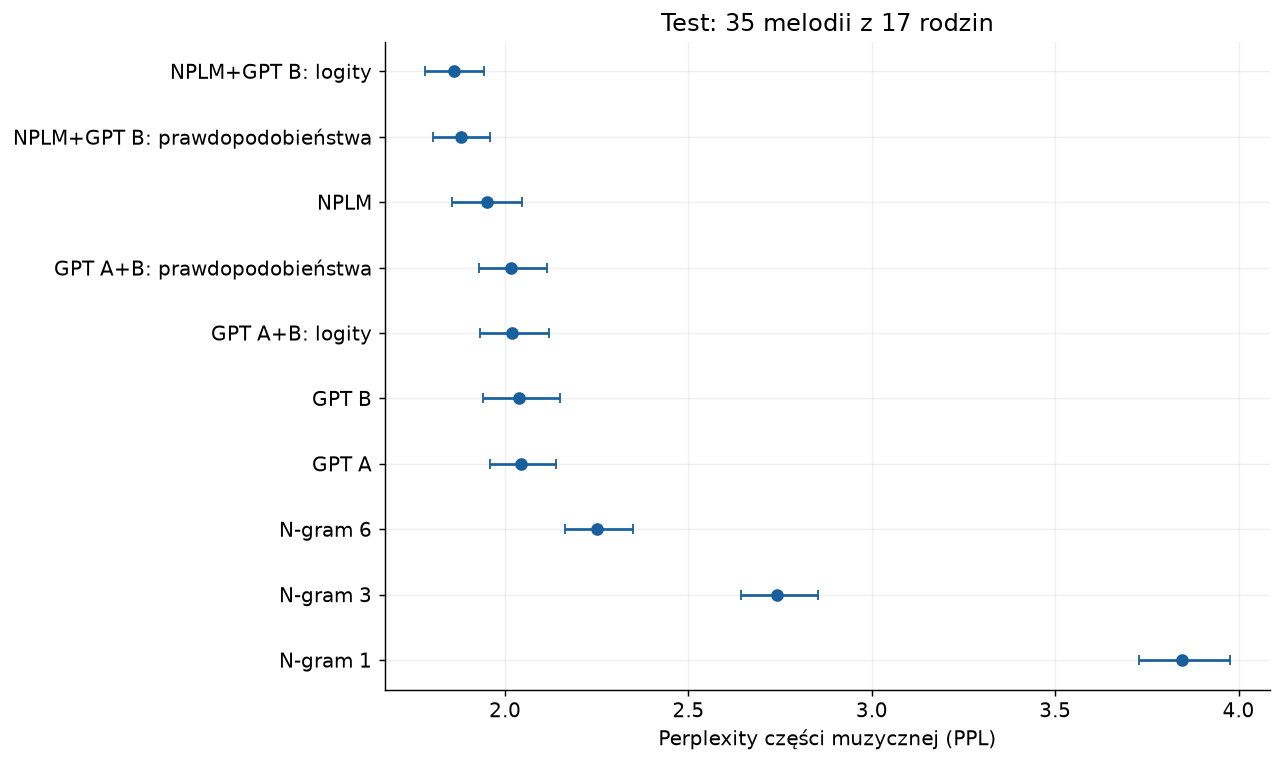

In [3]:
fig,ax=plt.subplots(figsize=(10,6))
y=np.arange(len(df));m=df['Test PPL'].to_numpy()
ax.errorbar(m,y,xerr=np.vstack([m-df['Dolne 95%'],df['Górne 95%']-m]),fmt='o',color='#185f9e',capsize=3)
ax.set_yticks(y,df['Model']);ax.invert_yaxis();ax.set_xlabel('Perplexity części muzycznej (PPL)');ax.set_title('Test: 35 melodii z 17 rodzin')
finish('test_ppl.png')


### 2. Sparowane różnice

Przedział różnicy NLL nie przechodzi przez zero dla głównej pary NPLM–GPT B. Pozostałe porównania są eksploracyjne; nie zastosowano korekty wielokrotnego testowania.

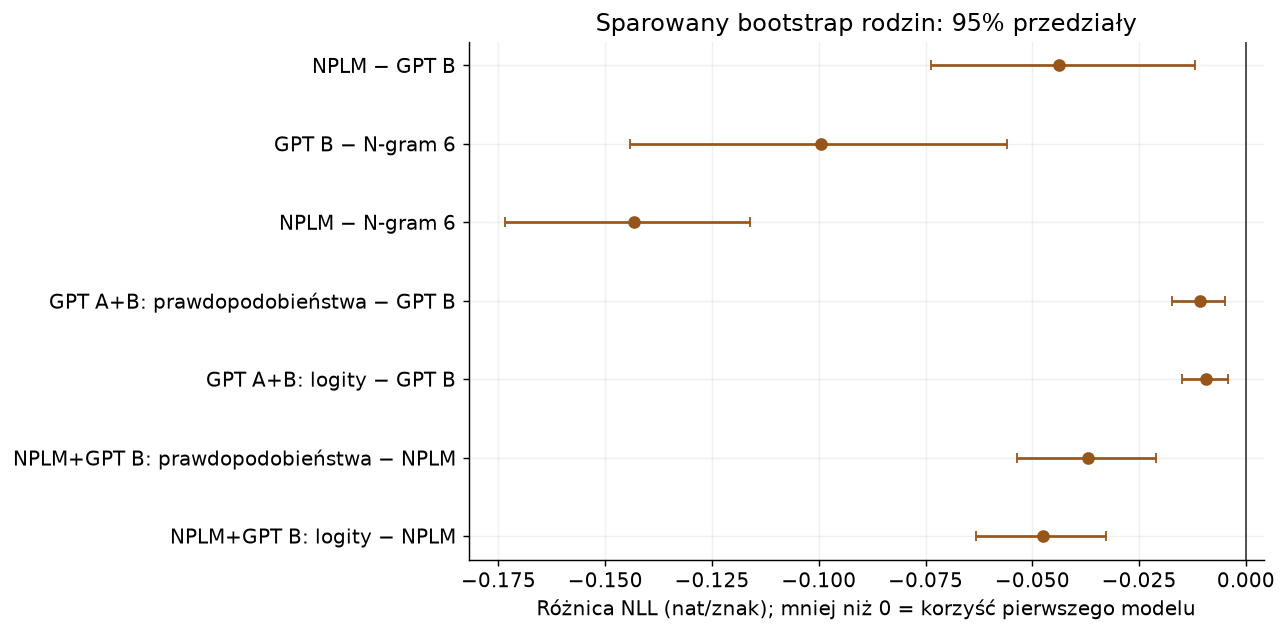

In [4]:
pairs=R['test']['comparisons']; vals=np.array([r['delta_NLL_A_minus_B'] for r in pairs]);lo=np.array([r['delta_ci95'][0] for r in pairs]);hi=np.array([r['delta_ci95'][1] for r in pairs])
fig,ax=plt.subplots(figsize=(10,5));y=np.arange(len(pairs))
ax.errorbar(vals,y,xerr=np.vstack([vals-lo,hi-vals]),fmt='o',capsize=3,color='#985519');ax.axvline(0,color='#444',lw=1)
ax.set_yticks(y,[labels[r['A']]+' − '+labels[r['B']] for r in pairs]);ax.invert_yaxis();ax.set_xlabel('Różnica NLL (nat/znak); mniej niż 0 = korzyść pierwszego modelu');ax.set_title('Sparowany bootstrap rodzin: 95% przedziały')
finish('paired_differences.png')


### 3. Krzywe walidacji

Checkpointy wybrano przed testem; krzywe nie są wynikami testowymi.

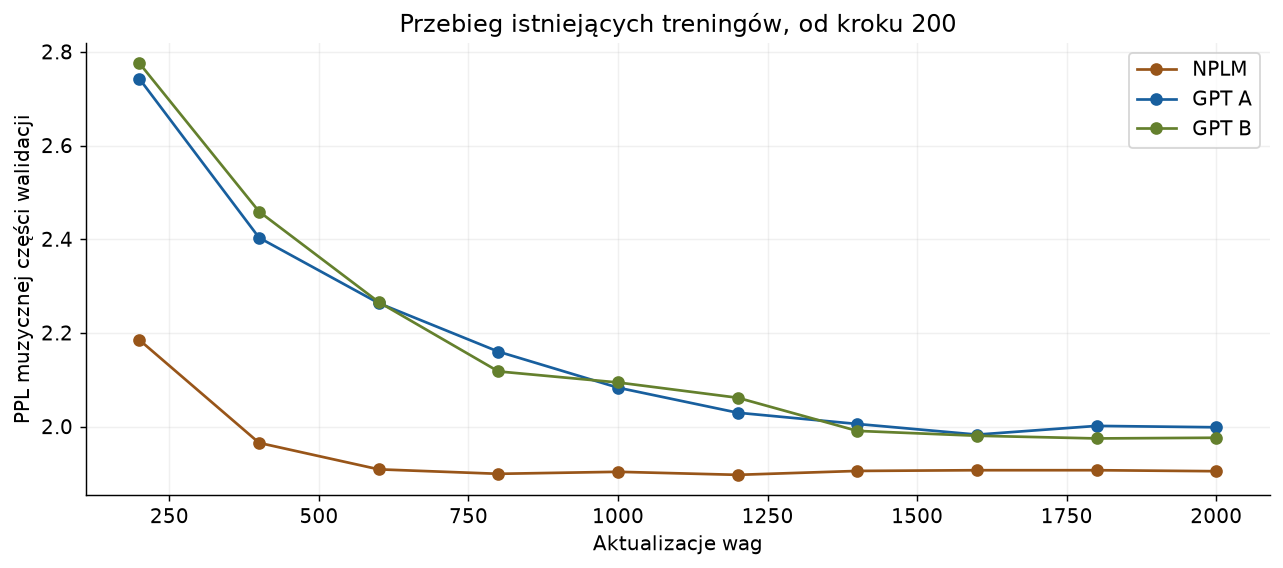

In [5]:
fig,ax=plt.subplots(figsize=(10,4.5))
for name,path,color in [('NPLM','nplm_92c0801c_seed_20260926','#985519'),('GPT A','gpt_92c0801c_seed_20260926','#185f9e'),('GPT B','gpt_92c0801c_seed_20260927','#64802d')]:
    logs=[json.loads(l) for l in (P.parent/'runs'/path/'metrics.jsonl').read_text().splitlines()]
    logs=[r for r in logs if r['step']>0]
    ax.plot([r['step'] for r in logs],[r['validation']['body_ppl'] for r in logs],marker='o',label=name,color=color)
ax.set_xlabel('Aktualizacje wag');ax.set_ylabel('PPL muzycznej części walidacji');ax.set_title('Przebieg istniejących treningów, od kroku 200');ax.legend()
finish('validation_curves.png')


### 4. Generacje

| Model | Odczytane przez parser | EOS | Próbki z błędnym metrum | Zakończone i bez wykrytych błędów metrum | Mediana nowych tokenów |
|---|---:|---:|---:|---:|---:|
| NPLM | 29/30 | 25/30 | 14/30 | 15/30 | 130 |
| GPT A | 30/30 | 19/30 | 21/30 | 7/30 | 354.5 |
| GPT B | 27/30 | 12/30 | 22/30 | 3/30 | 384 |

Wykonano wszystkie 90 zaplanowanych losowań: trzy nagłówki (G-dur 4/4, a-moll 4/4, D-dur 3/4), po dziesięć seedów, temperatura 0,8, top-k 20, najwyżej 384 nowych tokenów. Nagłówki nie zawierają melodii z testu. Nie poprawiano surowych ABC, nie odrzucano nieudanych wyników i nie powtarzano losowań w poszukiwaniu lepszej próbki.

EOS oznacza zakończenie wybrane przez model; osiągnięcie limitu jest ucięciem. Kontrola metrum pomija pierwszy i ostatni takt, aby nie karać automatycznie przedtaktu i zakończenia. Próbka musi zawierać przynajmniej jeden takt wewnętrzny, aby spełnić łączny warunek. Parser music21 bywa tolerancyjny, dlatego jego akceptacja nie jest ścisłym dowodem poprawności ABC.

Liczba błędnych taktów wśród odczytanych wyniosła 45/405 dla NPLM, 53/833 dla GPT A i 64/728 dla GPT B. NPLM częściej kończy krótki utwór, natomiast GPT generują dłuższe sekwencje i mają więcej okazji do popełnienia błędu. Nie można więc z samego odsetka próbek bez błędu wywnioskować lepszego frazowania lub muzykalności NPLM. Dodatkowo cztery nieodczytane próbki nie wnosi taktów do tych mianowników. Nie przeprowadzano ślepego odsłuchu ani oceny przez muzyków.

Także niska PPL znakowa wymaga kontekstu: spacje stanowią 29,8% muzycznej części testu, a znaki alteracji (=, ^, _) kolejne 23,0%. To własność naszego jawnego kodowania. Trafność dla liter nut i pauzy wyniosła 56,0% NPLM, 54,8% GPT B i 59,0% hybrydy logitowej; pełna trafność znakowa odpowiednio 76,0%, 75,3% i 78,1%. Litery są przybliżeniem diagnostycznym, nie kompletnymi zdarzeniami muzycznymi.

,samples,parser_accepted,EOS,with_interior_meter_errors,without_testable_meter,bad_measures,interior_measures,complete_and_meter_check_pass,median_generated_tokens
NPLM,30.0,29.0,25.0,14.0,1.0,45.0,405.0,15.0,130.0
GPT_A,30.0,30.0,19.0,21.0,0.0,53.0,833.0,7.0,354.5
GPT_B,30.0,27.0,12.0,22.0,3.0,64.0,728.0,3.0,384.0


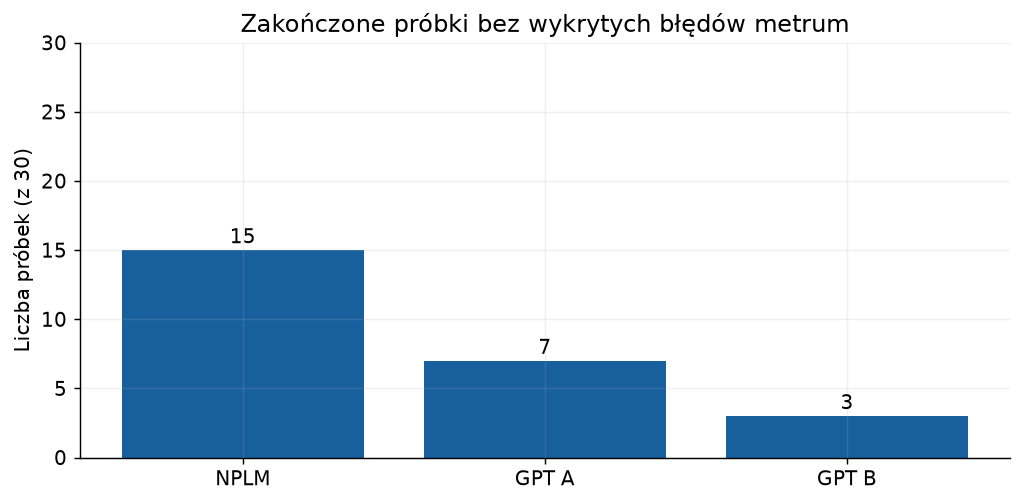

In [6]:
display(pd.DataFrame(G['summary']).T)
fig,ax=plt.subplots(figsize=(8,4));names=['NPLM','GPT_A','GPT_B'];v=[G['summary'][n]['complete_and_meter_check_pass'] for n in names]
ax.bar([labels[n] for n in names],v,color='#185f9e');ax.set_ylim(0,30);ax.set_ylabel('Liczba próbek (z 30)');ax.set_title('Zakończone próbki bez wykrytych błędów metrum')
for i,n in enumerate(v):ax.text(i,n+.5,str(n),ha='center')
finish('generation_checks.png')


### 5. CKA i kontrola losowa

Na 1536 tych samych pozycji muzycznych z walidacji średnia linear CKA dwóch GPT wyniosła 0,908. W kolejnych blokach: 0,897, 0,870, 0,909 i 0,957. Dwa modele losowe tej samej architektury uzyskały średnio 0,645, a model wytrenowany z losowym 0,490. Po przetasowaniu zgodności obserwacji CKA spada do 0,0055; dla modelu porównanego z samym sobą wynosi 1.

Kontrola losowa jest konieczna: wspólne znaki, pozycje i konstrukcja sieci mogą tworzyć podobieństwo także bez treningu. Wynik 0,908 wskazuje stabilność reprezentacji pomiędzy tymi dwoma seedami. Nie dowodzi pełnej redundancji, wspólnej semantyki, „platońskiej konwergencji” ani możliwości bezstratnego połączenia różnych modeli.

Wykonano też kontrolę E0 z łącznikiem identycznościowym po drugim bloku GPT A. Maksymalna różnica logitów wyniosła 0,0. To kontrola poprawności przepływu przez łączenie. Nie jest treningiem losowego mappera z E0 ani eksperymentem E1 między specjalistami. W CKA nie wykonano sweepu rozmiarów ani wielu niezależnych par kontrolnych.

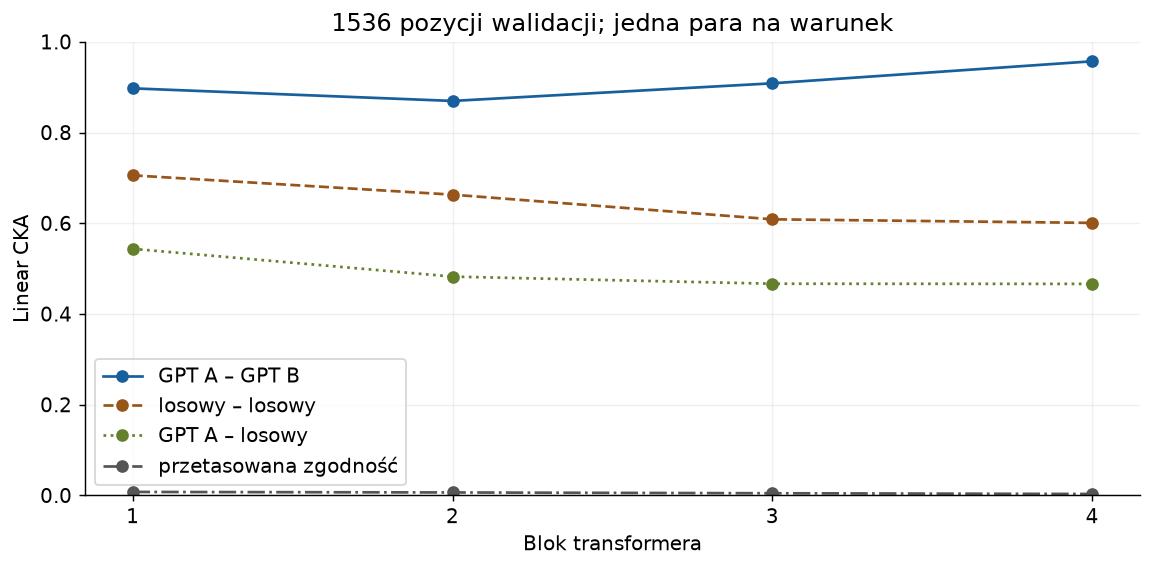

In [7]:
fig,ax=plt.subplots(figsize=(9,4.5))
for name,label,color,style in [('GPT_A__GPT_B','GPT A – GPT B','#185f9e','-'),('random_A__random_B','losowy – losowy','#985519','--'),('GPT_A__random_A','GPT A – losowy','#64802d',':'),('shuffled_alignment','przetasowana zgodność','#555555','-.')]:
    ax.plot(C['layers'],C['CKA'][name],marker='o',color=color,linestyle=style,label=label)
ax.set_ylim(0,1);ax.set_xticks([1,2,3,4]);ax.set_xlabel('Blok transformera');ax.set_ylabel('Linear CKA');ax.set_title('1536 pozycji walidacji; jedna para na warunek');ax.legend()
finish('cka.png')


## Takeaways

**Wniosek:** na tym zbiorze nie ma uzasadnienia, by odrzucać NPLM na rzecz większego transformera. Jest tańszym, silnym punktem odniesienia. **Wniosek:** połączenie NPLM i GPT poprawia predykcję na odłożonych rodzinach; dwa podobne GPT dają znacznie mniejszy przyrost. **Wniosek:** modele nie są jeszcze niezawodnymi generatorami poprawnych melodii.

**Hipoteza 1:** krótki kontekst i mały, regularny korpus sprzyjają NPLM. Rozstrzygający eksperyment powinien zmieniać kontekst i rozmiar przy porównywalnym budżecie oraz obejmować więcej seedów. **Hipoteza 2:** odmienna architektura wnosi użyteczną komplementarność; można spróbować destylacji hybrydy do małego ucznia. **Hipoteza 3:** reprezentacja zdarzeń muzycznych albo dekoder pilnujący sumy wartości rytmicznych poprawią metrum bardziej niż samo dalsze minimalizowanie PPL znakowej.

Następny zamknięty eksperyment powinien porównać dekodowanie zwykłe i ograniczone metrum przy tych samych promptach, seedach i długościach oraz mierzyć odsetek poprawnych taktów, kompletność, kopiowanie fragmentów i jakość w ślepym odsłuchu. Ograniczenia gramatyki nie mogą poprawiać jedynie raportowanej metryki przez przedwczesne kończenie utworów. Kryterium sukcesu trzeba ustalić wcześniej.

W tej turze nie uruchomiono nowych treningów na już obejrzanym teście. Dalsze strojenie wymaga nowej, rozłącznej puli oceny lub z góry zaplanowanej grupowej walidacji krzyżowej. Ten test można nadal raportować jako historyczny benchmark, z jawną informacją o wcześniejszym wykorzystaniu.

Pozostają otwarte: trening mappera E0, E1 między rzeczywistymi ekspertami różnych domen, powtórzenia treningów, sweep CKA, judge odpowiedni dla chorałów i eksperymenty Obsidian na udostępnionych notatkach. Do samego zbadania ensemble i CKA dwóch dostępnych GPT dodatkowy korpus nie był potrzebny; skorygowano zbyt szerokie wcześniejsze oznaczenie tego etapu jako zablokowanego.

## Raport metodologiczny i porównanie z repozytorium

### Co daje łączenie modeli

Dwa GPT trenowane na tym samym korpusie dają niewielką korzyść z ensemble: średnia prawdopodobieństw obniża PPL z 2,0375 do 2,0159, czyli o 1,06%. Połączenie NPLM z GPT B daje większą poprawę: 1,8792 dla średniej prawdopodobieństw oraz 1,8595 dla średniej logitów.

Wagi wynosiły zawsze 50/50. Listę tych wariantów zapisano przed pierwszym obliczeniem wyniku testowego. Średnia logitów, używana w E1 repozytorium, odpowiada znormalizowanej średniej geometrycznej rozkładów; średnia prawdopodobieństw jest mieszaniną arytmetyczną. To różne operacje. W tym eksperymencie hybryda logitowa była także lepsza na walidacji; nie wybierano proporcji na teście.

Niepewność eksploracyjna poprawy hybrydy logitowej względem NPLM: iloraz PPL 0,954, przedział 95% 0,939–0,968; poprawa w 15/17 rodzin. Warianty dodatkowe nie mają korekty na wielokrotne porównania.

NPLM i GPT B różnią się najczęstszą predykcją na 18,09% pozycji; dwa GPT na 8,28%. Dla pary NPLM–GPT B wystąpiło 590 pozycji poprawnych tylko dla NPLM i 530 poprawnych tylko dla GPT. Dla pary GPT A–B było ich 249 i 266. Korelacja strat znakowych wynosi odpowiednio 0,750 i 0,954. Te obserwacje wspierają hipotezę komplementarnych błędów, ale sama rozbieżność prognoz nie wystarczyłaby jako dowód użyteczności ensemble.

Ensemble wymaga wykonywania obu modeli; nie jest scaleniem wag ani nowym pojedynczym modelem. Nie zmierzono jego szybkości generowania ani jakości muzycznej. Wynik uzasadnia późniejsze zbadanie destylacji do jednego małego ucznia.

### Jak ewaluacja zmieniała się w repozytorium

Przejrzano historię Git i źródła głównej gałęzi `da30da3` oraz końcówkę gałęzi PR 13 `496f856`. Daty niżej są datami commitów; notatki eksperymentalne mogą opisywać wcześniejszą pracę. Nie założono, że tekst najnowszego raportu opisuje wszystkie historyczne wersje pomiaru.

| Etap | Pomiar i istotna zmiana |
|---|---|
| Początek repo, 21.06, `9666355` | GPT, E0 i ensemble; muzyczne korpusy znakowe; podział strumienia 90/10. |
| CKA, 21.06, `d828550` → `0e1b3c7` → `8a1fb5f` | Podobieństwo aktywacji, następnie sweep skali i seedy. |
| Audyt CKA, `1e8607f` | Zmieniono probe; mutual-kNN wycofano jako rozstrzygający dowód, bo kontrola losowa dawała podobny sygnał. |
| N-gram/NPLM, `44d272a` | Dodano interpolowane n-gramy oraz MLP ze stałym kontekstem. |
| CKA, 23.06, `b1bb1d0` | Baseline losowy osobno dla każdej skali, zamiast jednej poziomej wartości na wykresie. |
| Obsidian, 28.06, `ced0e1a` | Porównanie n-gramu, GPT raw i GPT decomp w bitach na znak wspólnego raw held-out. |
| Main, 04.09, `da30da3` | Usunięto wagi z aktualnego drzewa; ich historia pozostaje w Git. |
| PR 13, 04–05.09, `fc53efa` → `496f856` | Judge klasyfikujący cechy muzyki, benchmark scratch/continuation, forward/reverse KL i wybór best/last. Gałąź odrębna od main. |

W [treningu GPT](https://github.com/slayerlabs/micro-models/blob/da30da3d7486a4b6b3de8d2d4aaa0f183617f751/music-experts/src/train/train_gpt.py) loss walidacji jest średnią ze 100 losowych partii po 32 okna długości 128. To około 409,6 tys. pozycji z możliwymi powtórzeniami, a nie jednokrotna ocena każdej pozycji. NPLM ocenia 200 partii po 64 pojedyncze cele dla kontekstu 8 lub 16. N-gram przechodzi walidację znak po znaku, pomijając pierwszy znak. Wspólny korpus nie oznacza zatem identycznego ważenia pozycji i dostępnego kontekstu.

W [E1](https://github.com/slayerlabs/micro-models/blob/da30da3d7486a4b6b3de8d2d4aaa0f183617f751/music-experts/src/compose/e1_stitch.py) porównuje się te same losowane partie, lecz najpierw skraca dłuższy korpus do długości krótszego. W połączeniu z wcześniejszym treningiem eksperta na 90% pełnego korpusu może to wpuścić dane wcześniejszego treningu do późniejszej walidacji. Uzasadnienie dotyczy kodu i opisywanych długości; brak manifestu historycznego nie pozwala potwierdzić każdego checkpointu. Nie ma podstaw, by przypisać autorom celowe manipulowanie.

W Obsidianie stara funkcja [bits_per_char](https://github.com/slayerlabs/micro-models/blob/da30da3d7486a4b6b3de8d2d4aaa0f183617f751/obsidian-experts/eval_obsidian.py) pomija końcowe niepełne okno, a mianownik obejmuje cały tekst. To może zaniżać metrykę. Ponadto n-gram i GPT nie korzystają z identycznej puli treningowej. Nie odtwarzano wyniku na prywatnych notatkach, więc nie wiadomo, czy poprawki odwróciłyby ranking.

W PR 13 judge ocenia prawdopodobieństwo prawdziwych etykiet metrum i trybu, a w continuation także typu. Błędy generacji w obrębie domeny mają dawać zero. Probe continuation obejmuje prefiks prawdziwej melodii, więc wynik nie izoluje samej nowej kontynuacji. Kod wyłącza Bach (`type=null`) z tej domeny benchmarkowej. Dodatkowo w odczytanej wersji budowanie ciała używa `prompt + raw`, choć `generate` już zwraca prompt; może to dublować prefiks continuation. To obserwacja kodu, nie oszacowanie wpływu na publikowane wyniki. Z tego powodu nie przypisano naszym modelom pozornej punktacji judge z innej domeny.

### Porównanie z badaniami autorów

[Raport autorów](https://github.com/slayerlabs/micro-models/blob/da30da3d7486a4b6b3de8d2d4aaa0f183617f751/REPORT.md) podaje na jigach PPL około 3,90 dla n-gramu 6, 4,38 dla NPLM 16 i 3,80 dla GPT. Ich wniosek ilościowy: GPT jest blisko mocnego n-gramu, a NPLM jest gorszy w tej konfiguracji. W naszym pilotażu Bach kolejność jest inna: NPLM, GPT, n-gram. To różnica wyników dwóch eksperymentów; nie dowód, że nasze modele pokonały ich modele.

| Wymiar | Autorzy | Nasz pilotaż |
|---|---|---|
| Korpus podstawowego porównania | Jigi The Session | Sopran chorałów Bacha |
| Podział | Odcinek strumienia 90/10 | Rozłączne rodziny, 281/36/35 melodii |
| Tokenizacja muzyki | Alfabet korpusu, typowo 52 znaki | Zadeklarowane 79 znaków + PAD/BOS/EOS |
| PPL | Różne schematy losowania/oceny | Każdy znak raz, osobno muzyka i cały tekst |
| Ensemble | Logity dwóch stylów | Logity lub prawdopodobieństwa modeli na tych samych danych |
| CKA | Różne style i sweep skali | Dwa seedy GPT na Bach, jedna skala |

Nie umieszczamy PPL 3,80 autorów i 1,95 naszego NPLM na wspólnej osi sugerującej ranking. Różnią się trudność tekstu, kodowanie, liczba znaków, podział, trening i ewaluacja. Również CKA 0,945 autorów oraz nasze 0,908 mają inne probe i kontrole, więc ich różnica nie jest miarą poprawy lub pogorszenia.

Wspólny wniosek jakościowy jest węższy: złożoność architektury nie gwarantuje przewagi, a prosty baseline i kontrole losowe są niezbędne. Nasze wyniki dodatkowo pokazują korzyść z łączenia różnych mechanizmów predykcji. Nie stanowią reprodukcji E1, benchmarku judge ani wyników prywatnego Obsidiana.

### Założenia, metodologia i przebieg badań

Pierwsza seria wykorzystała cyfrowe wydanie Craig Stuart Sapp — 370 chorałów, commit `0fd9e00542445a522c6030c80c687b874aa569d5`, z zachowaną licencją CC BY-NC-SA 4.0. Analizowano wyłącznie sopran. Po usunięciu 18 identycznych melodii pozostały 352 zapisy. Rodziny budowano z metadanych i podobieństwa tekstowego oraz nutowego; po obniżeniu progu do 80% powstało 169 grup. Pierwsze rozpoczęte przebiegi na wcześniejszym podziale odrzucono i finalne modele wytrenowano od zera.

Grupowanie jest konserwatywne, a jego spójne składowe mogą łączyć pośrednio podobne utwory. Największa grupa ma 79 melodii. To ogranicza elastyczność podziału i nie jest twierdzeniem, że wszystkie melodie w grupie są historycznie jednym utworem. Rozdział wybrano na podstawie liczebności, długości, tonacji, trybu i metrum, bez wyników modeli. Nie wykryto przecięć według zapisanych reguł, ale nie jest to gwarancja wykrycia każdej relacji muzycznej.

Dwa rzadkie tryby/metryczne przypadki i część rzadkich wartości rytmicznych nie mają pełnego pokrycia w train/held-out. Wnioski dotyczą dominującej części tego małego korpusu, a nie wszystkich stylów i metrum. W testach podziału sprawdzano zawartość testu, ale przed obecną turą nie mierzono na nim jakości predykcji.

W treningu użyto FP32, tych samych danych i słownika, 2000 kroków, batch 32, okna 128 i stride 64. Cele nie przekraczały granic utworów. Checkpointy wybrano według minimum pełnej walidacyjnej straty części muzycznej: NPLM krok 1200, GPT A 1600, GPT B 1800. Najlepszy seed GPT B wybrano z walidacji. N-gram używa interpolacji kontekstów 0…M z wagami proporcjonalnymi do 2^M i dodatnim wygładzaniem unigramowym.

Przed testem zapisano hashe wag, metryki, modele, reguły obu ensemble i plan generacji/CKA. Protokół zamrożono około 03:25 czasu polskiego 26.09.2026. Test sprawdzono dla wszystkich zaplanowanych wariantów bez aktualizacji wag. Główne porównanie ustalone przed testem to NPLM versus GPT B; pozostałe traktujemy jako eksploracyjne.

NLL agreguje się po znakach, dopiero potem stosuje exp. Nie uśredniamy perplexity poszczególnych melodii. Dodatkowa kontrola równych wag rodzin daje zbliżony porządek: NPLM 1,9499, GPT B 2,0474, n-gram 6 2,2698, hybryda logitowa 1,8634. Ranking dwóch bliskich seedów GPT może zależeć od ważenia; bezwzględne różnice między nimi są małe.

Bootstrap losuje z powtórzeniem 17 całych rodzin, zachowując wszystkie należące do nich melodie, i używa tych samych losowań dla każdej pary modeli. Wykonano 10 tys. replikacji. Przedziały obejmują zmienność tego zbioru rodzin, warunkowo na wytrenowanych wagach i wybranym podziale. Nie obejmują wyboru hiperparametrów, niepewności grupowania ani losowości ponownego treningu.

Kontrola implementacji odtworzyła walidację z odchyleniem PPL najwyżej 4,8×10⁻⁸ (inna, równoważna ścieżka liczenia log-softmax). Potwierdzono pokrycie wszystkich znaków i normalizację rozkładów. Zmiana przyszłych wejść nie zmieniła wcześniejszych predykcji. Wzór CKA sprawdzono przez niezależne obliczenie na macierzach Grama. Wagi i dane pozostały identyczne bajtowo. To kontrole obliczeniowe, nie recenzja drugiego badacza.

In [8]:
checks=json.loads((P/'evaluation_checks.json').read_text())
assert checks['all_targets_scored_once'] and checks['all_distributions_normalized'] and checks['frozen_weights_unchanged']
assert max(checks['validation_reproduction_absolute_errors'].values())<1e-6
print('Kontrole obliczeń i odtworzenia walidacji: PASS. Środowisko:', checks['runtime'])


Kontrole obliczeń i odtworzenia walidacji: PASS. Środowisko: {'python': '3.12.14', 'torch': '2.14.0+cpu', 'numpy': '2.5.3'}
